In [1]:
#set up

from google.colab import drive
drive.mount('/content/drive')

import shutil
import os

if not os.path.exists('/content/data_split'):
    print("Copying from Drive...")
    shutil.copytree('/content/drive/MyDrive/varroa_project/data_split',
                    '/content/data_split')
    print("Done!")
else:
    print("data_split already exists locally, skipping...")

for split in ['train', 'val', 'test']:
    for class_name in ['varroa', 'not_varroa']:
        path = f'/content/data_split/{split}/{class_name}'
        count = len(os.listdir(path))
        print(f"  {split}/{class_name}: {count} images")

Mounted at /content/drive
Copying from Drive...
Done!
  train/varroa: 886 images
  train/not_varroa: 3692 images
  val/varroa: 190 images
  val/not_varroa: 791 images
  test/varroa: 190 images
  test/not_varroa: 791 images


In [2]:
import tensorflow as tf
import keras as k
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as sm


In [22]:
#load data

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

#load train ds: size to 150 x 150, make batch size 32, and shuffle
train_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/data_split/train',
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = True
)

#load val ds: size to 150 x 150, make batch size 32, and shuffle
val_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/data_split/val',
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = False
)

#load test ds: size to 150 x 150, make batch size 32, and shuffle
test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/data_split/test',
    image_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    shuffle = False
)

print("classes: " , train_ds.class_names)

Found 4578 files belonging to 2 classes.
Found 981 files belonging to 2 classes.
Found 981 files belonging to 2 classes.
classes:  ['not_varroa', 'varroa']


In [23]:
#performance, so GPU doesn't stay idle

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size = AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size = AUTOTUNE)

In [6]:
#data augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1)
])

In [6]:
#transfer learning using MobileNetV2

base_model = tf.keras.applications.MobileNetV2(
    input_shape = (150, 150, 3),
    include_top = False,
    weights = 'imagenet'
)

#freezes backbone aka prevents retraining

base_model.trainable = False

#building model

inputs = tf.keras.Input(shape = (150, 150, 3))
x = data_augmentation(inputs)
x = base_model(x, training = False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(1, activation = 'sigmoid')(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

/tmp/ipykernel_32063/542870227.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [25]:
#compiling with class weights
total = 886 + 3692 #combining varroa training imgs + not varroa ___
weight_for_varroa = (1/886) * total / 2 #makes this weight more, because there are less images
weight_for_not_varroa = (1/3692) * total / 2

class_weights = {
    0: weight_for_not_varroa,
    1: weight_for_varroa
}

print('Class weights: ', class_weights)

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss = 'binary_crossentropy',
    metrics = ['accuracy', tf.keras.metrics.AUC(name = 'auc')]
)

Class weights:  {0: 0.6199891657638136, 1: 2.5835214446952595}


In [11]:
#train model

history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 20,
    class_weight = class_weights
)


Epoch 1/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 87s 567ms/step - accuracy: 0.5168 - auc: 0.5307 - loss: 0.7648 - val_accuracy: 0.5688 - val_auc: 0.7280 - val_loss: 0.6932
Epoch 2/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 71s 495ms/step - accuracy: 0.6073 - auc: 0.6508 - loss: 0.6700 - val_accuracy: 0.7390 - val_auc: 0.7679 - val_loss: 0.5277
Epoch 3/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 73s 505ms/step - accuracy: 0.6081 - auc: 0.6685 - loss: 0.6549 - val_accuracy: 0.7003 - val_auc: 0.7837 - val_loss: 0.5393
Epoch 4/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 82s 507ms/step - accuracy: 0.6260 - auc: 0.6929 - loss: 0.6376 - val_accuracy: 0.7115 - val_auc: 0.7877 - val_loss: 0.5304
Epoch 5/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 73s 510ms/step - accuracy: 0.6269 - auc: 0.6978 - loss: 0.6301 - val_accuracy: 0.6942 - val_auc: 0.7986 - val_loss: 0.5608
Epoch 6/20
144/144 ━━━━━━━━━━━━━━━━━━━━ 81s 506ms/step - accuracy: 0.6289 - auc: 0.7049 - loss: 0.6277 - val_accuracy: 0.6799 - val_auc: 0.8031 - val_loss: 0.5865
Epoch 7/20
144/144 ━━━

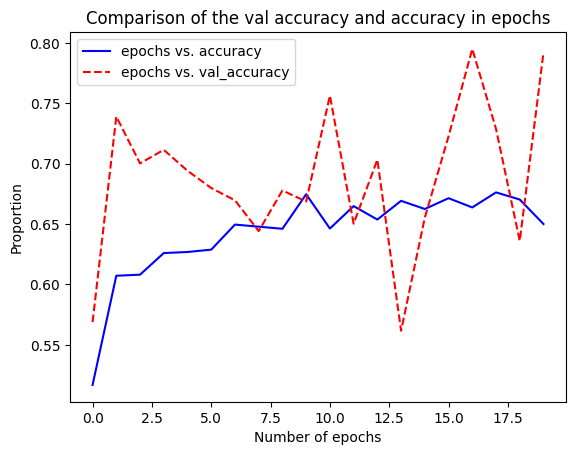

In [23]:
#plotting training history

#first graph: both accuracy and val accuracy over number of epochs

epochs = history.epoch
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

plt.figure(1)
plt.plot(epochs, accuracy, label = 'epochs vs. accuracy', color = 'blue', linestyle = '-')
plt.plot(epochs, val_accuracy, label = 'epochs vs. val_accuracy', color = 'red',
         linestyle = '--')

plt.xlabel('Number of epochs')
plt.ylabel('Proportion')
plt.title('Comparison of the val accuracy and accuracy in epochs')
plt.legend()
plt.show()


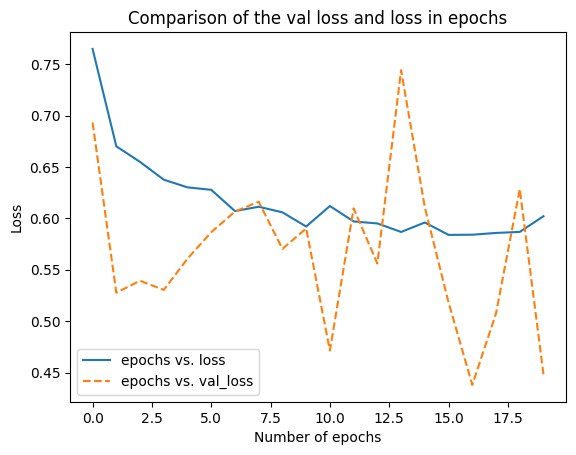

In [27]:
#second graph: plotting loss and val loss

loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(2)
plt.plot(epochs, loss, label = 'epochs vs. loss', linestyle = '-')
plt.plot(epochs, val_loss, label = 'epochs vs. val_loss', linestyle = '--')

plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.title('Comparison of the val loss and loss in epochs')
plt.legend()
plt.show()


In [14]:
#save model and history after first round of training:
model.save('/content/drive/MyDrive/varroa_project/models/varroa_model_v1.keras')
print("Model saved!")

import json

with open('/content/drive/MyDrive/varroa_project/models/history_v1.json', 'w') as f:
    json.dump(history.history, f)

print("History saved!")


Model saved!
History saved!


In [3]:
# load model and history
import json
model = tf.keras.models.load_model('/content/drive/MyDrive/varroa_project/models/varroa_model_v1.keras')

with open('/content/drive/MyDrive/varroa_project/models/history_v1.json', 'r') as f:
    history_data = json.load(f)

In [34]:
base_model = model.layers[2]
print(base_model.name)

0 input_layer_1
1 sequential
2 mobilenetv2_1.00_224
3 global_average_pooling2d
4 dropout
5 dense
mobilenetv2_1.00_224


In [35]:
#fine tuning
base_model.trainable = True

for layer in base_model.layers[:100]:
  layer.trainable = False

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-5),
    loss = 'binary_crossentropy',
    metrics = ['accuracy', tf.keras.metrics.AUC(name = 'auc')]
)

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,862,721 (7.11 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [36]:
#retraining with fine-tuned model
history_fine = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 30,
    initial_epoch = 20,
    class_weight = class_weights
)


Epoch 21/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 149s 949ms/step - accuracy: 0.7955 - auc: 0.5501 - loss: 3.6286 - val_accuracy: 0.8094 - val_auc: 0.7858 - val_loss: 0.4991
Epoch 22/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 123s 823ms/step - accuracy: 0.6029 - auc: 0.6424 - loss: 0.7445 - val_accuracy: 0.7554 - val_auc: 0.7902 - val_loss: 0.4586
Epoch 23/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 148s 865ms/step - accuracy: 0.6387 - auc: 0.6880 - loss: 0.6784 - val_accuracy: 0.7105 - val_auc: 0.7847 - val_loss: 0.5449
Epoch 24/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 139s 848ms/step - accuracy: 0.6356 - auc: 0.7166 - loss: 0.6354 - val_accuracy: 0.6707 - val_auc: 0.7907 - val_loss: 0.6167
Epoch 25/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 121s 842ms/step - accuracy: 0.6429 - auc: 0.7119 - loss: 0.6405 - val_accuracy: 0.6432 - val_auc: 0.7938 - val_loss: 0.6512
Epoch 26/30
144/144 ━━━━━━━━━━━━━━━━━━━━ 118s 822ms/step - accuracy: 0.6590 - auc: 0.7160 - loss: 0.6344 - val_accuracy: 0.6290 - val_auc: 0.7986 - val_loss: 0.6702
Epoch 27/3

In [37]:
#save model v2 and fine tuned history

model.save('/content/drive/MyDrive/varroa_project/models/varroa_model_v2.keras')

import json
with open('/content/drive/MyDrive/varroa_project/models/history_fine_v1.json', 'w') as f:
    json.dump(history_fine.history, f)

In [6]:
#load fine tuned model:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import json

model = tf.keras.models.load_model('/content/drive/MyDrive/varroa_project/models/varroa_model_v2.keras')

with open('/content/drive/MyDrive/varroa_project/models/history_fine_v1.json', 'r') as f:
    history_fine_data = json.load(f)

print("Model loaded!")
print(f"Epochs recorded: {len(history_fine_data['accuracy'])}")

import shutil
import os

if not os.path.exists('/content/data_split'):
    shutil.copytree('/content/drive/MyDrive/varroa_project/data_split',
                    '/content/data_split')
    print("Data copied!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded!
Epochs recorded: 10


In [7]:
#combine history across all epochs:
import json

#both histories
with open('/content/drive/MyDrive/varroa_project/models/history_v1.json', 'r') as f:
    history_phase1 = json.load(f)

with open('/content/drive/MyDrive/varroa_project/models/history_fine_v1.json', 'r') as f:
    history_phase2 = json.load(f)

#combining
combined_history = {}
for key in history_phase1.keys():
    combined_history[key] = history_phase1[key] + history_phase2[key]

print(f"Total epochs: {len(combined_history['accuracy'])}")


Total epochs: 30


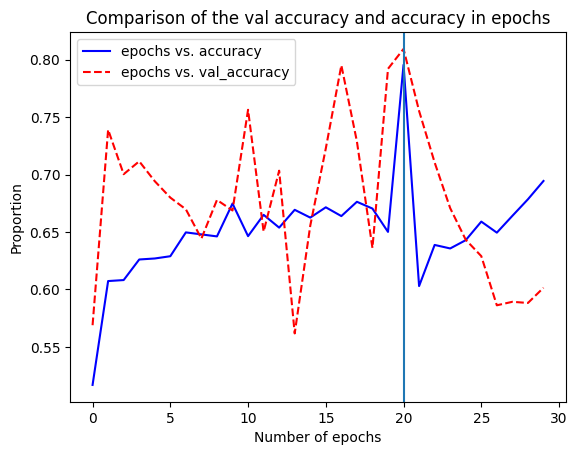

In [8]:
combined_epochs = list(range(len(combined_history['accuracy'])))
accuracy = combined_history['accuracy']
val_accuracy = combined_history['val_accuracy']

plt.figure(3)
plt.plot(combined_epochs, accuracy, label = 'epochs vs. accuracy', color = 'blue', linestyle = '-')
plt.plot(combined_epochs, val_accuracy, label = 'epochs vs. val_accuracy', color = 'red',
         linestyle = '--')

plt.xlabel('Number of epochs')
plt.ylabel('Proportion')
plt.axvline(x=20, ymin = 0)
plt.title('Comparison of the val accuracy and accuracy in epochs')
plt.legend()
plt.show()

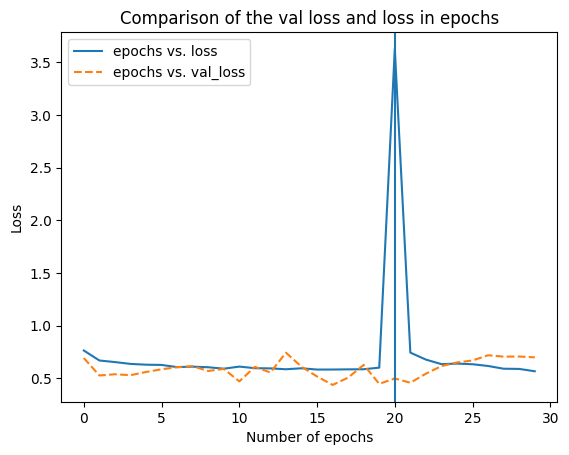

In [9]:
loss = combined_history['loss']
val_loss = combined_history['val_loss']

plt.figure(4)
plt.plot(combined_epochs, loss, label = 'epochs vs. loss', linestyle = '-')
plt.plot(combined_epochs, val_loss, label = 'epochs vs. val_loss', linestyle = '--')

plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.axvline(x=20, ymin = 0)
plt.title('Comparison of the val loss and loss in epochs')
plt.legend()
plt.show()

In [10]:
#evaluating on test set
import tensorflow as tf

IMG_SIZE = (150, 150)
BATCH_SIZE = 32

test_ds = tf.keras.utils.image_dataset_from_directory(
    '/content/data_split/test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False  # important — keep False for evaluation
)

print("Classes:", test_ds.class_names)


model.evaluate(test_ds, verbose = 1)




Found 981 files belonging to 2 classes.
Classes: ['not_varroa', 'varroa']
31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 520ms/step - accuracy: 0.5994 - auc: 0.7784 - loss: 0.7231


[0.7231366038322449, 0.5993883609771729, 0.7784283757209778]

In [11]:
#prediction labels

predictions = model.predict(test_ds, verbose = 1)
predicted_labels = (predictions > 0.5).astype(int)


31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 548ms/step


In [12]:
#true labels

true_labels = []

for images, labels, in test_ds:
  true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

In [13]:
#confusion matrix
cm = sm.confusion_matrix(true_labels, predicted_labels)

print(cm)

#classification report
cr = sm.classification_report(true_labels, predicted_labels,
                              target_names = ['not_varroa', 'varroa'])
print(cr)

[[418 373]
 [ 20 170]]
              precision    recall  f1-score   support

  not_varroa       0.95      0.53      0.68       791
      varroa       0.31      0.89      0.46       190

    accuracy                           0.60       981
   macro avg       0.63      0.71      0.57       981
weighted avg       0.83      0.60      0.64       981



In [14]:
#retrain model with more epochs (set up)
base_model = model.layers[2]

base_model.trainable = True

for layer in base_model.layers[:100]:
  layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,862,721 (7.11 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [33]:
#retraining model with more epochs:

history_fine2 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 50,
    initial_epoch=30,
    class_weight = class_weights
)

Epoch 31/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 223s 1s/step - accuracy: 0.6623 - auc: 0.7497 - loss: 0.6756 - val_accuracy: 0.8084 - val_auc: 0.5457 - val_loss: 3.4033
Epoch 32/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.7429 - auc: 0.8308 - loss: 0.5107 - val_accuracy: 0.8695 - val_auc: 0.7655 - val_loss: 1.7421
Epoch 33/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.7951 - auc: 0.8814 - loss: 0.4301 - val_accuracy: 0.7727 - val_auc: 0.8382 - val_loss: 1.1618
Epoch 34/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.8087 - auc: 0.8873 - loss: 0.4295 - val_accuracy: 0.8063 - val_auc: 0.5053 - val_loss: 2.0233
Epoch 35/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.8283 - auc: 0.9077 - loss: 0.3912 - val_accuracy: 0.8634 - val_auc: 0.8993 - val_loss: 0.4585
Epoch 36/50
144/144 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.7049 - auc: 0.7941 - loss: 0.5515 - val_accuracy: 0.8073 - val_auc: 0.8056 - val_loss: 0.5935
Epoch 37/50
144/144 ━━━━━━━━

In [37]:
#save model
model.save('/content/drive/MyDrive/varroa_project/models/varroa_model_v3.keras')

import json
with open('/content/drive/MyDrive/varroa_project/models/history_fine_v2.json', 'w') as f:
    json.dump(history_fine2.history, f)

print("Saved!")

Saved!


In [38]:
#load fine tuned2 model
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import json

model = tf.keras.models.load_model('/content/drive/MyDrive/varroa_project/models/varroa_model_v3.keras')

with open('/content/drive/MyDrive/varroa_project/models/history_fine_v2.json', 'r') as f:
    history_fine_data = json.load(f)

print("Model loaded!")
print(f"Epochs recorded: {len(history_fine_data['accuracy'])}")

import shutil
import os

if not os.path.exists('/content/data_split'):
    shutil.copytree('/content/drive/MyDrive/varroa_project/data_split',
                    '/content/data_split')
    print("Data copied!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded!
Epochs recorded: 20


In [39]:
#combine history across all epochs:

import json

#both histories
with open('/content/drive/MyDrive/varroa_project/models/history_v1.json', 'r') as f:
    history_phase1 = json.load(f)

with open('/content/drive/MyDrive/varroa_project/models/history_fine_v1.json', 'r') as f:
    history_phase2 = json.load(f)

with open('/content/drive/MyDrive/varroa_project/models/history_fine_v2.json', 'r') as f:
    history_phase3 = json.load(f)

#combining
combined_history = {}
for key in history_phase1.keys():
    combined_history[key] = history_phase1[key] + history_phase2[key] + history_phase3[key]

print(f"Total epochs: {len(combined_history['accuracy'])}")

Total epochs: 50


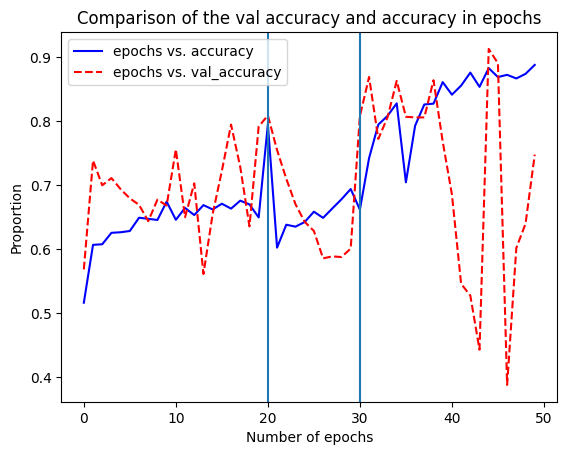

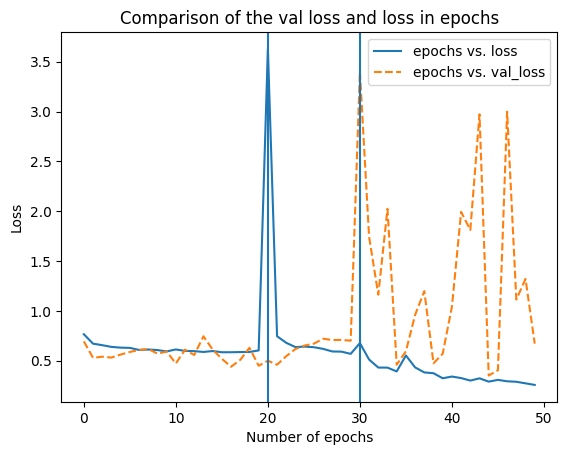

In [40]:
#create accuracy and loss plot for up to 50 epochs
combined_epochs = list(range(len(combined_history['accuracy'])))
accuracy = combined_history['accuracy']
val_accuracy = combined_history['val_accuracy']

plt.figure(5)
plt.plot(combined_epochs, accuracy, label = 'epochs vs. accuracy', color = 'blue', linestyle = '-')
plt.plot(combined_epochs, val_accuracy, label = 'epochs vs. val_accuracy', color = 'red',
         linestyle = '--')

plt.xlabel('Number of epochs')
plt.ylabel('Proportion')
plt.axvline(x=20, ymin = 0)
plt.axvline(x=30, ymin = 0)
plt.title('Comparison of the val accuracy and accuracy in epochs')
plt.legend()
plt.show()


#loss
loss = combined_history['loss']
val_loss = combined_history['val_loss']

plt.figure(6)
plt.plot(combined_epochs, loss, label = 'epochs vs. loss', linestyle = '-')
plt.plot(combined_epochs, val_loss, label = 'epochs vs. val_loss', linestyle = '--')

plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.axvline(x=20, ymin = 0)
plt.axvline(x=30, ymin = 0)
plt.title('Comparison of the val loss and loss in epochs')
plt.legend()
plt.show()

In [41]:
#evaluation
model.evaluate(test_ds, verbose = 1)

31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 528ms/step - accuracy: 0.7452 - auc: 0.9461 - loss: 0.7294


[0.7294496893882751, 0.7451580166816711, 0.946144163608551]

In [42]:
#prediction labels

predictions_2 = model.predict(test_ds, verbose = 1)
predicted_labels2 = (predictions_2 > 0.5).astype(int)

31/31 ━━━━━━━━━━━━━━━━━━━━ 18s 544ms/step


In [43]:
#truth labels

true_labels = []

for images, labels, in test_ds:
  true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

In [44]:
#confusion matrix and classification report

cm = sm.confusion_matrix(true_labels, predicted_labels2)

print(cm)


cr = sm.classification_report(true_labels, predicted_labels,
                              target_names = ['not_varroa', 'varroa'])
print(cr)

[[552 239]
 [ 11 179]]
              precision    recall  f1-score   support

  not_varroa       0.95      0.53      0.68       791
      varroa       0.31      0.89      0.46       190

    accuracy                           0.60       981
   macro avg       0.63      0.71      0.57       981
weighted avg       0.83      0.60      0.64       981



In [19]:
#retraining model_v2 again, because overfitting occured last model
model = tf.keras.models.load_model(
    '/content/drive/MyDrive/varroa_project/models/varroa_model_v2.keras'
)

base_model = model.layers[2]

base_model.trainable = True

for layer in base_model.layers[:100]:
  layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()


v2 loaded!


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,862,721 (7.11 MB)

 Non-trainable params: 396,544 (1.51 MB)

In [20]:
#creating callbacks to overwrite best model

early_stopping = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss',
                                                  patience = 5,
                                                  restore_best_weights = True)

model_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '/content/drive/MyDrive/varroa_project/models/varroa_model_v4_best.keras',
    monitor = 'val_auc',
    save_best_only = True,
    mode = 'max'
)



In [26]:
#training model:

history_best = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 60,
    initial_epoch = 30,
    class_weight = class_weights,
    callbacks = [early_stopping, model_checkpoint]
)


Epoch 31/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.6249 - auc: 0.7384 - loss: 0.6101 - val_accuracy: 0.8063 - val_auc: 0.5000 - val_loss: 6.5203
Epoch 32/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.7444 - auc: 0.8359 - loss: 0.5005 - val_accuracy: 0.8848 - val_auc: 0.8636 - val_loss: 0.5611
Epoch 33/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step - accuracy: 0.7969 - auc: 0.8721 - loss: 0.4523 - val_accuracy: 0.8491 - val_auc: 0.9000 - val_loss: 0.3907
Epoch 34/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 210s 1s/step - accuracy: 0.8080 - auc: 0.8991 - loss: 0.4011 - val_accuracy: 0.6239 - val_auc: 0.8421 - val_loss: 2.1877
Epoch 35/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.8294 - auc: 0.9143 - loss: 0.3704 - val_accuracy: 0.3242 - val_auc: 0.6669 - val_loss: 5.3823
Epoch 36/60
144/144 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.8351 - auc: 0.9178 - loss: 0.3646 - val_accuracy: 0.8063 - val_auc: 0.7837 - val_loss: 0.4399
Epoch 37/60
144/144 ━━━━━━━━

In [27]:
#save best model
model.save('/content/drive/MyDrive/varroa_project/models/varroa_model_v4.keras')

import json
with open('/content/drive/MyDrive/varroa_project/models/history_best.json', 'w') as f:
    json.dump(history_best.history, f)

print("Saved!")

Saved!


In [28]:
#load best model

from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import json

model = tf.keras.models.load_model('/content/drive/MyDrive/varroa_project/models/varroa_model_v4.keras')

with open('/content/drive/MyDrive/varroa_project/models/history_best.json', 'r') as f:
    history_best_data = json.load(f)

print("Model loaded!")
print(f"Epochs recorded: {len(history_best_data['accuracy'])}")

import shutil
import os

if not os.path.exists('/content/data_split'):
    shutil.copytree('/content/drive/MyDrive/varroa_project/data_split',
                    '/content/data_split')
    print("Data copied!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded!
Epochs recorded: 8


In [29]:
#combine history across all epochs for best model:

import json

#both histories
with open('/content/drive/MyDrive/varroa_project/models/history_v1.json', 'r') as f:
    history_phase1 = json.load(f)

with open('/content/drive/MyDrive/varroa_project/models/history_fine_v1.json', 'r') as f:
    history_phase2 = json.load(f)

with open('/content/drive/MyDrive/varroa_project/models/history_best.json', 'r') as f:
    history_phase3 = json.load(f)

#combining
combined_history = {}
for key in history_phase1.keys():
    combined_history[key] = history_phase1[key] + history_phase2[key] + history_phase3[key]

print(f"Total epochs: {len(combined_history['accuracy'])}")

Total epochs: 38


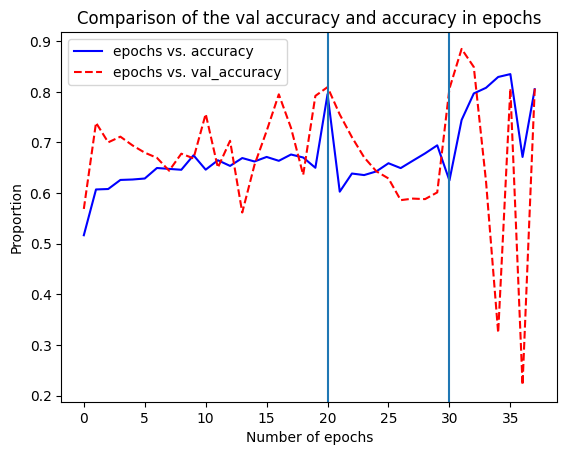

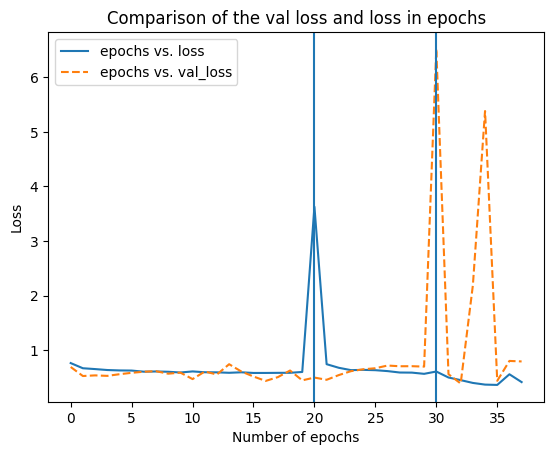

In [30]:
#create accuracy and loss plot for best model
combined_epochs = list(range(len(combined_history['accuracy'])))
accuracy = combined_history['accuracy']
val_accuracy = combined_history['val_accuracy']

plt.figure(7)
plt.plot(combined_epochs, accuracy, label = 'epochs vs. accuracy', color = 'blue', linestyle = '-')
plt.plot(combined_epochs, val_accuracy, label = 'epochs vs. val_accuracy', color = 'red',
         linestyle = '--')

plt.xlabel('Number of epochs')
plt.ylabel('Proportion')
plt.axvline(x=20, ymin = 0)
plt.axvline(x=30, ymin = 0)
plt.title('Comparison of the val accuracy and accuracy in epochs')
plt.legend()
plt.show()


#loss
loss = combined_history['loss']
val_loss = combined_history['val_loss']

plt.figure(8)
plt.plot(combined_epochs, loss, label = 'epochs vs. loss', linestyle = '-')
plt.plot(combined_epochs, val_loss, label = 'epochs vs. val_loss', linestyle = '--')

plt.xlabel('Number of epochs')
plt.ylabel('Loss')
plt.axvline(x=20, ymin = 0)
plt.axvline(x=30, ymin = 0)
plt.title('Comparison of the val loss and loss in epochs')
plt.legend()
plt.show()

In [31]:
#evaluation
model.evaluate(test_ds, verbose = 1)

31/31 ━━━━━━━━━━━━━━━━━━━━ 20s 551ms/step - accuracy: 0.8430 - auc: 0.8952 - loss: 0.4170


[0.41702014207839966, 0.8430173397064209, 0.8952258825302124]

In [39]:
#prediction labels

predictions = model.predict(test_ds, verbose=1)
predicted_labels = (predictions > 0.5).astype(int)

31/31 ━━━━━━━━━━━━━━━━━━━━ 19s 616ms/step


In [33]:
#truth labels

true_labels = []

for images, labels, in test_ds:
  true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)

In [40]:
#confusion matrix and classification report for best model

cm = sm.confusion_matrix(true_labels, predicted_labels2)

print(cm)


cr = sm.classification_report(true_labels, predicted_labels,
                              target_names = ['not_varroa', 'varroa'])
print(cr)

[[681 110]
 [ 44 146]]
              precision    recall  f1-score   support

  not_varroa       0.94      0.86      0.90       791
      varroa       0.57      0.77      0.65       190

    accuracy                           0.84       981
   macro avg       0.75      0.81      0.78       981
weighted avg       0.87      0.84      0.85       981

